In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# =========================
# LOAD DATASET
# =========================

data = pd.read_excel('battery dataset.xlsx')

print(data.head())
X = data[[
    'VELOCITY(m/s)',
    'HEAT SOURCE(W/m3)',
    'INLET TEMP(K)'
]]
y = data['MAX BATTERY TEMP(K)']

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# RANDOM FOREST MODEL
# =========================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

predictions = model.predict(X_test)

# =========================
# ACCURACY
# =========================

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('\nModel Performance')
print('-------------------')
print(f'Mean Absolute Error: {mae:.3f}')
print(f'R2 Score: {r2:.3f}')

   VELOCITY(m/s)  HEAT SOURCE(W/m3)  INLET TEMP(K)  MAX BATTERY TEMP(K)  \
0            1.0                 50            300             390.7818   
1            1.5                 50            300             387.5250   
2            2.0                 50            300             378.5552   
3            3.0                 50            300             386.5459   
4            4.0                 50            300             377.8794   

   average temp(k)  pressure drop  
0         379.5036       30.58132  
1         377.0101       68.77656  
2         370.6535      122.26460  
3         376.1327      275.13090  
4         370.0379      489.32520  

Model Performance
-------------------
Mean Absolute Error: 3.904
R2 Score: 0.969


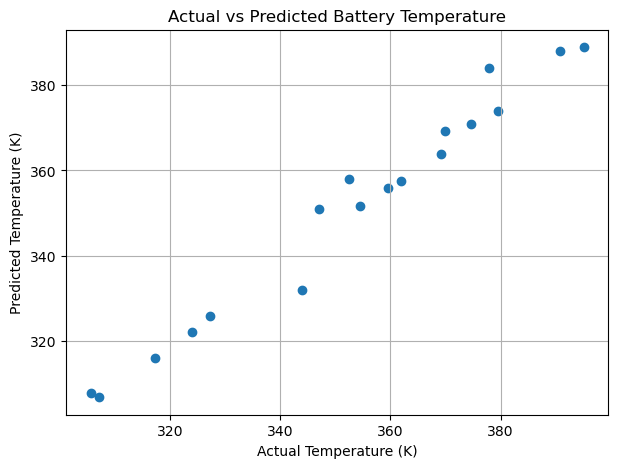


Optimized Prediction
-------------------
Predicted Battery Temperature: 332.06 K


In [6]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, predictions)
plt.xlabel('Actual Temperature (K)')
plt.ylabel('Predicted Temperature (K)')
plt.title('Actual vs Predicted Battery Temperature')
plt.grid(True)
plt.show()
new_case = pd.DataFrame({
    'VELOCITY(m/s)': [5],
    'HEAT SOURCE(W/m3)': [20],
    'INLET TEMP(K)': [300]
})

predicted_temp = model.predict(new_case)

print('\nOptimized Prediction')
print('-------------------')
print(f'Predicted Battery Temperature: {predicted_temp[0]:.2f} K')


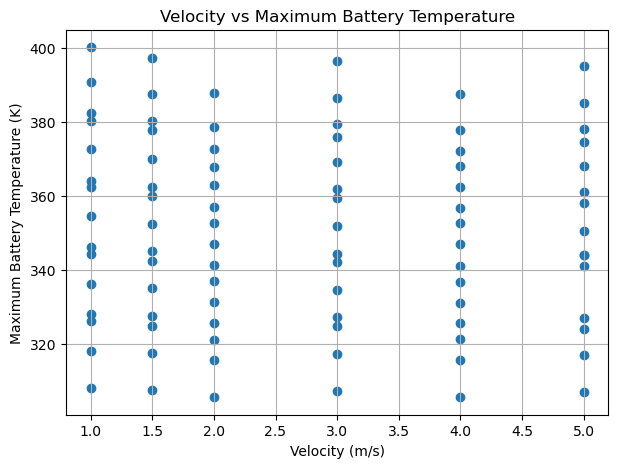

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    data['VELOCITY(m/s)'],
    data['MAX BATTERY TEMP(K)']
)

plt.xlabel('Velocity (m/s)')
plt.ylabel('Maximum Battery Temperature (K)')
plt.title('Velocity vs Maximum Battery Temperature')

plt.grid(True)

plt.show()

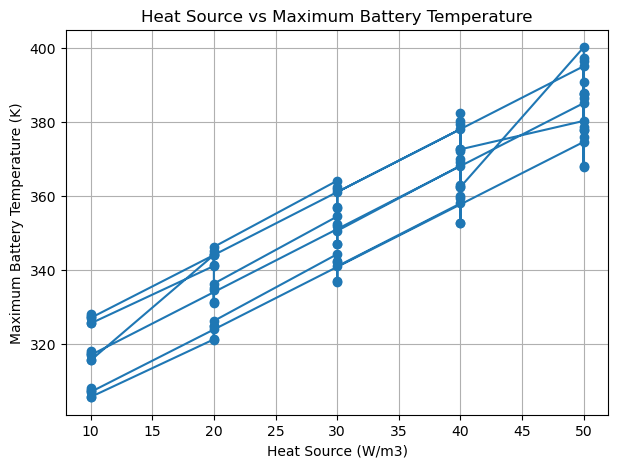

In [8]:
plt.figure(figsize=(7,5))

plt.plot(
    data['HEAT SOURCE(W/m3)'],
    data['MAX BATTERY TEMP(K)'],
    marker='o'
)

plt.xlabel('Heat Source (W/m3)')
plt.ylabel('Maximum Battery Temperature (K)')
plt.title('Heat Source vs Maximum Battery Temperature')
plt.grid(True)

plt.show()

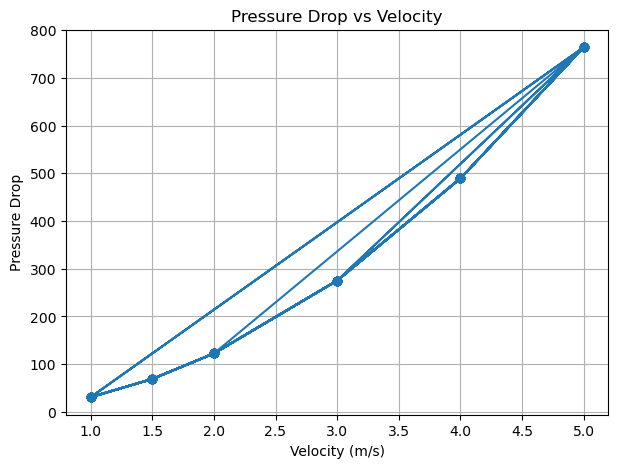

In [9]:
plt.figure(figsize=(7,5))

plt.plot(
    data['VELOCITY(m/s)'],
    data['pressure drop'],
    marker='o'
)

plt.xlabel('Velocity (m/s)')
plt.ylabel('Pressure Drop')
plt.title('Pressure Drop vs Velocity')
plt.grid(True)

plt.show()

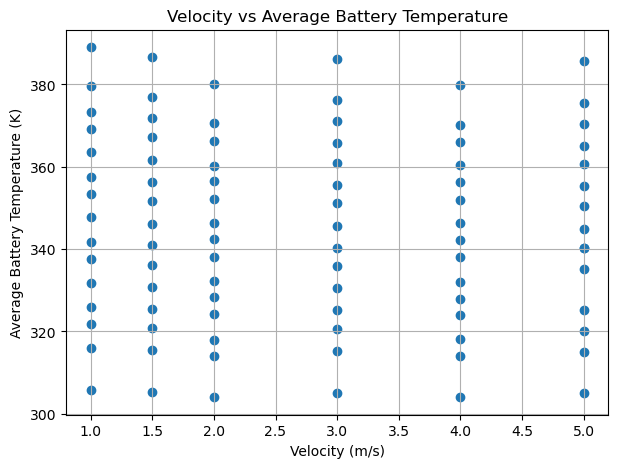

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(
    data['VELOCITY(m/s)'],
    data['average temp(k)']
)

plt.xlabel('Velocity (m/s)')
plt.ylabel('Average Battery Temperature (K)')
plt.title('Velocity vs Average Battery Temperature')

plt.grid(True)

plt.show()

In [14]:
optimized = data.sort_values(
    by=['MAX BATTERY TEMP(K)', 'pressure drop'],
    ascending=[True, True]
)

print("Top Optimized Cooling Conditions")
print(optimized.head(10))

Top Optimized Cooling Conditions
    VELOCITY(m/s)  HEAT SOURCE(W/m3)  INLET TEMP(K)  MAX BATTERY TEMP(K)  \
39            2.0                 10            290             305.5953   
41            4.0                 10            290             305.6437   
36            5.0                 10            290             306.9992   
40            3.0                 10            290             307.2121   
38            1.5                 10            290             307.4757   
37            1.0                 10            290             308.1105   
11            4.0                 10            300             315.5428   
9             2.0                 10            300             315.7060   
6             5.0                 10            300             316.9768   
10            3.0                 10            300             317.2903   

    average temp(k)  pressure drop  
39         304.0264      122.26460  
41         304.0701      489.32520  
36         305.0954

In [15]:

data['Performance Score'] = (
    data['MAX BATTERY TEMP(K)'] * 0.7 +
    data['pressure drop'] * 0.3
)

best_case = data.sort_values(
    by='Performance Score'
)

print("Best Overall Cooling Configuration")
print(best_case.head(10))

Best Overall Cooling Configuration
    VELOCITY(m/s)  HEAT SOURCE(W/m3)  INLET TEMP(K)  MAX BATTERY TEMP(K)  \
37            1.0                 10            290             308.1105   
7             1.0                 10            300             318.1564   
38            1.5                 10            290             307.4757   
47            1.0                 20            290             326.2253   
67            1.0                 10            310             328.1206   
8             1.5                 10            300             317.5239   
17            1.0                 20            300             336.3127   
46            1.5                 20            290             324.9513   
68            1.5                 10            310             327.4392   
48            1.0                 30            290             344.2763   

    average temp(k)  pressure drop  Performance Score  
37         305.8565       30.58132         224.851746  
7          315.9

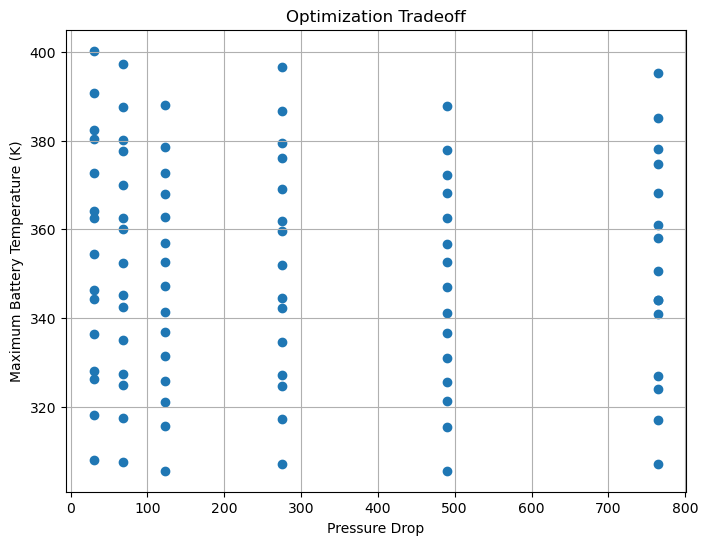

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['pressure drop'],
    data['MAX BATTERY TEMP(K)']
)

plt.xlabel('Pressure Drop')
plt.ylabel('Maximum Battery Temperature (K)')

plt.title('Optimization Tradeoff')

plt.grid(True)

plt.show()

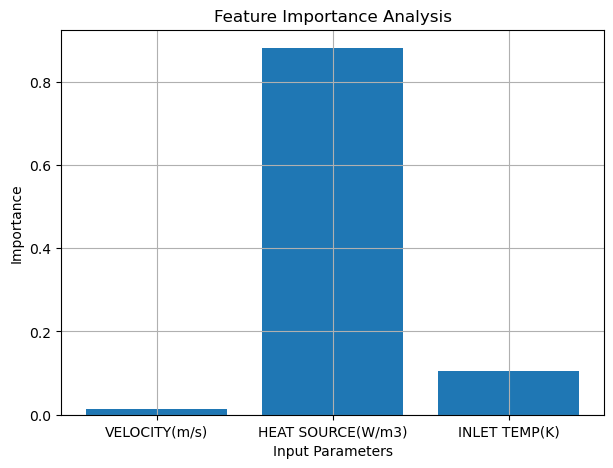

In [17]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(7,5))

plt.bar(features, importance)

plt.xlabel('Input Parameters')
plt.ylabel('Importance')

plt.title('Feature Importance Analysis')

plt.grid(True)

plt.show()